<a href="https://colab.research.google.com/github/tirthas970-cmyk/AeroTrack-Prime/blob/main/Cross_Attention_v4_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive, userdata

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from huggingface_hub import snapshot_download
from google.colab import userdata
import os

print("Beginning filtered download of v2 .tar shards from Hugging Face Hub...")
print("This process may take some time depending on your network speed and the size of the files.")

try:
    local_data_path = snapshot_download(
        repo_id="X-FlareNet/solar-flare-magnetogram-shards",
        repo_type="dataset",
        token=userdata.get("hf_token"),
        local_dir="/content/local_solar_shards",
        allow_patterns=["*v2*.tar"]
    )
    print(f"\n[SUCCESS] v2 shards downloaded locally at: {local_data_path}")
    print("Checking remaining disk space:")
    os.system("df -h /content")
    print(f"\nListing contents of the download directory: {local_data_path}")
    os.system(f"ls -l {local_data_path}")
except Exception as e:
    print(f"\n[ERROR] Filtered download failed: {e}")
finally:
    print("\nFile download process concluded.")

Beginning filtered download of v2 .tar shards from Hugging Face Hub...
This process may take some time depending on your network speed and the size of the files.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 339 files:   0%|          | 0/339 [00:00<?, ?it/s]


[SUCCESS] v2 shards downloaded locally at: /content/local_solar_shards
Checking remaining disk space:

Listing contents of the download directory: /content/local_solar_shards

File download process concluded.


In [4]:


with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/train_ars.txt", "r") as f:
    train_set = set(int(line.strip()) for line in f if line.strip())

with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/val_ars.txt", "r") as f:
    val_set = set(int(line.strip()) for line in f if line.strip())

with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/test_ars.txt", "r") as f:
    test_set = set(int(line.strip()) for line in f if line.strip())

print(f"[SUCCESS] Loaded {len(train_set)} training regions and {len(val_set)} validation regions back into RAM!")


[SUCCESS] Loaded 716 training regions and 122 validation regions back into RAM!


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# 1. Your Original V4 Balanced Focal Loss Class (Unchanged!)
class V4BalancedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        if alpha is not None:
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_weight = (1.0 - p_t) ** self.gamma
        loss = focal_weight * ce_loss

        if self.alpha is not None:
            at = self.alpha[targets]
            loss = at * loss

        return loss.mean()


# 2. Calculate Weights for the Binary Head (Quiet vs. Any Flare)
quiet_count = 44472
total_flares = 1631 + 194
binary_counts = np.array([quiet_count, total_flares], dtype=np.float32)
binary_inv_freq = binary_counts.sum() / binary_counts
binary_log_weights = np.log(binary_inv_freq) + 1.0
binary_weights_tensor = torch.tensor(binary_log_weights / binary_log_weights[0], dtype=torch.float32).cuda()


# 3. Calculate Weights for the Severity Head (M-Class vs. X-Class)
severity_counts = np.array([1631, 194], dtype=np.float32)
severity_inv_freq = severity_counts.sum() / severity_counts
severity_log_weights = np.log(severity_inv_freq) + 1.0
severity_weights_tensor = torch.tensor(severity_log_weights / severity_log_weights[0], dtype=torch.float32).cuda()


# 4. Hierarchical Wrapper using your V4 Focal Loss
class HierarchicalV4FocalLoss(nn.Module):
    def __init__(self, binary_alpha, severity_alpha, gamma=2.0):
        super().__init__()
        self.binary_focal = V4BalancedFocalLoss(alpha=binary_alpha, gamma=gamma)
        self.severity_focal = V4BalancedFocalLoss(alpha=severity_alpha, gamma=gamma)

    def forward(self, binary_logits, severity_logits, targets):
        # A. Binary targets: 0 if Quiet (target == 0), 1 if Flare (target > 0)
        binary_targets = (targets > 0).long()
        loss_binary = self.binary_focal(binary_logits, binary_targets)

        # B. Severity mask: Only select samples that are actual flares (targets > 0)
        severity_mask = (targets > 0)

        if severity_mask.sum() > 0:
            # Map M-Class (1) -> 0, X-Class (2) -> 1
            severity_targets = torch.clamp(targets[severity_mask] - 1, min=0)
            loss_severity = self.severity_focal(severity_logits[severity_mask], severity_targets)
        else:
            loss_severity = torch.tensor(0.0, device=binary_logits.device)

        # Combine both focal losses
        return loss_binary + loss_severity


# 5. Instantiate your final criterion ready for the training script!
criterion = HierarchicalV4FocalLoss(
    binary_alpha=binary_weights_tensor,
    severity_alpha=severity_weights_tensor,
    gamma=2.0
)

AssertionError: Torch not compiled with CUDA enabled

In [6]:
import torch
import torch.nn as nn
import torchvision.models as models
import math

class Verified2DPositionalEncoding(nn.Module):
    """Injects error-free 2D spatial coordinate awareness into sequence-first image tokens."""
    def __init__(self, d_model, max_h=50, max_w=50):
        super().__init__()
        self.d_model = d_model
        assert d_model % 4 == 0, "Embed dim must be divisible by 4 for balanced 2D encoding"

        pe = torch.zeros(max_h, max_w, d_model)
        d_per_axis = d_model // 2  # 256 channels for H, 256 channels for W

        div_term = torch.exp(torch.arange(0, d_per_axis, 2).float() * (-math.log(10000.0) / d_per_axis))

        pos_h = torch.arange(0, max_h).unsqueeze(1).float()
        pos_w = torch.arange(0, max_w).unsqueeze(1).float()

        sin_h = torch.sin(pos_h * div_term)
        cos_h = torch.cos(pos_h * div_term)
        sin_w = torch.sin(pos_w * div_term)
        cos_w = torch.cos(pos_w * div_term)

        pe_h = torch.zeros(max_h, max_w, d_per_axis)
        pe_h[:, :, 0::2] = sin_h.unsqueeze(1).repeat(1, max_w, 1)
        pe_h[:, :, 1::2] = cos_h.unsqueeze(1).repeat(1, max_w, 1)

        pe_w = torch.zeros(max_h, max_w, d_per_axis)
        pe_w[:, :, 0::2] = sin_w.unsqueeze(0).repeat(max_h, 1, 1)
        pe_w[:, :, 1::2] = cos_w.unsqueeze(0).repeat(max_h, 1, 1)

        pe = torch.cat([pe_h, pe_w], dim=-1)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x, h, w):
        pe_sliced = self.pe[:, :h, :w, :].reshape(1, h * w, self.d_model)
        return x + pe_sliced


class SolarCrossAttention(nn.Module):
    def __init__(self, tabular_dim=9, embed_dim=512, num_heads=8):
        super().__init__()
        # 1. ResNet18 Backbone for Spatial Feature Extraction
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # 2. Position Injection Module
        self.pos_encoder = Verified2DPositionalEncoding(d_model=embed_dim)

        self.tabular_dim = tabular_dim
        self.embed_dim = embed_dim

        # 3. V7 Upgrade: Disentangled Physical Embedders
        self.param_embedders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, 64),
                nn.SiLU(),
                nn.Linear(64, embed_dim)
            ) for _ in range(tabular_dim)
        ])
        self.tab_norm = nn.LayerNorm(embed_dim)

        # 4. Attention Engine (Tabular = Query, Spatial = Key/Value)
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.fusion_norm = nn.LayerNorm(embed_dim)

        # 5. Lightweight Token Interaction Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=512,
            batch_first=True,
            dropout=0.1
        )
        self.token_aggregator = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # 6. TWO-HEAD ARCHITECTURE
        # Head 1: Gatekeeper (Quiet vs. Flare) -> Binary Output (2 classes)
        self.binary_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

        # Head 2: Severity Grader (M-Class vs. X-Class) -> Binary Output (2 classes)
        self.severity_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, images, tabular_data):
        B = images.size(0)

        # Backbone Spatial Extraction -> (B, 512, H', W')
        spatial_features = self.backbone(images)
        _, C, H_prime, W_prime = spatial_features.shape

        # Flatten image spatially -> (B, H'*W', embed_dim) and add positional encoding
        spatial_flat = spatial_features.view(B, C, -1).permute(0, 2, 1)
        spatial_positioned = self.pos_encoder(spatial_flat, H_prime, W_prime)

        # Disentangled Physical Embedding -> Query sequence of shape (B, 9, embed_dim)
        tab_tokens = []
        for i in range(self.tabular_dim):
            param_val = tabular_data[:, i:i+1]
            param_token = self.param_embedders[i](param_val)
            tab_tokens.append(param_token.unsqueeze(1))

        query_tab = torch.cat(tab_tokens, dim=1)
        query_tab = self.tab_norm(query_tab)

        # Cross Attention Execution
        attn_output, attn_weights = self.cross_attention(
            query=query_tab,
            key=spatial_positioned,
            value=spatial_flat
        )

        # Residual Fusion and Normalization
        fused_tokens = self.fusion_norm(attn_output + query_tab)

        # Token Interaction
        fused_tokens = self.token_aggregator(fused_tokens)

        # Global Average Pool over tokens to produce class vector -> (B, embed_dim)
        fused_pooled = fused_tokens.mean(dim=1)

        # Dual Head Logits Output
        binary_logits = self.binary_head(fused_pooled)
        severity_logits = self.severity_head(fused_pooled)

        return binary_logits, severity_logits, attn_weights

In [7]:
import io
import os
import tarfile
import glob
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

class SuperFastSolarDataset(Dataset):
    def __init__(self, local_dir, allowed_ar_set, csv_path, tabular_mean=None, tabular_std=None):
        print(f"Loading master tabular data from {csv_path}...")
        self.df = pd.read_csv(csv_path)
        self.df.set_index('key', inplace=True)
        self.allowed_ar_set = allowed_ar_set

        # Store scaling parameters (if provided)
        self.tabular_mean = tabular_mean
        self.tabular_std = tabular_std

        self.samples = []

        self.tar_files = sorted(glob.glob(os.path.join(local_dir, "**", "*.tar"), recursive=True))
        print(f"Indexing local files... Parsing headers from {len(self.tar_files)} shards.")

        for tar_path in self.tar_files:
            with tarfile.open(tar_path, "r") as tar:
                for member in tar.getmembers():
                    if member.isfile() and member.name.endswith('.npy'):
                        filename = member.name
                        base_key = filename.replace(".npy", "")
                        try:
                            first_part = base_key.split("_")[0]
                            ar_num = int(first_part.replace("AR", ""))

                            if ar_num in self.allowed_ar_set and base_key in self.df.index:
                                self.samples.append((tar_path, member, base_key))
                        except Exception:
                            continue

        print(f"Index complete! Found {len(self.samples)} valid frames.")
        self.labels = [int(self.df.loc[base_key]['label']) for _, _, base_key in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tar_path, tar_member, base_key = self.samples[idx]

        with tarfile.open(tar_path, "r") as tar:
            img_bytes = tar.extractfile(tar_member).read()

        img = np.load(io.BytesIO(img_bytes)).astype(np.float32)

        # Image data normalization
        solar_mask = (img != 0.0)
        norm_pixels = np.zeros_like(img, dtype=np.float32)
        clipped = np.clip(img[solar_mask], -4000.0, 4000.0)
        norm_pixels[solar_mask] = (clipped + 4000.0) / 8000.0
        img_3ch = np.repeat(norm_pixels[np.newaxis, :, :], 3, axis=0)
        img_tensor = torch.tensor(img_3ch, dtype=torch.float32)

        # Pull tabular features and labels
        csv_row = self.df.loc[base_key]
        tabular_features = csv_row.iloc[-9:].values.astype(np.float32)
        label_val = int(csv_row['label'])

        label_tensor = torch.tensor(label_val, dtype=torch.long)
        tabular_tensor = torch.tensor(tabular_features, dtype=torch.float32)
        tabular_tensor = torch.nan_to_num(tabular_tensor, nan=0.0, posinf=0.0, neginf=0.0)

        # --- TABULAR SCALING APPLIED HERE ---
        if self.tabular_mean is not None and self.tabular_std is not None:
            # Z-score normalization: (x - mean) / std (with a tiny epsilon to avoid division by zero)
            tabular_tensor = (tabular_tensor - self.tabular_mean) / (self.tabular_std + 1e-8)

        return img_tensor, tabular_tensor, label_tensor

In [8]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import WeightedRandomSampler, DataLoader

output_path = "/content/drive/MyDrive/Solar_Dataset_Project/solar_flare_61k_aligned_metadata_cleaned.csv"

# ==========================================
# 1. CALCULATE TRAIN-ONLY TABULAR STATS
# ==========================================
print("Calculating training set mean and std for tabular features...")
master_df = pd.read_csv(output_path)
master_df.set_index('key', inplace=True)

train_tabular_values = []
for base_key, row in master_df.iterrows():
    try:
        first_part = base_key.split("_")[0]
        ar_num = int(first_part.replace("AR", ""))
        # Only pull rows belonging to the training Active Region set
        if ar_num in train_set:
            train_tabular_values.append(row.iloc[-9:].values.astype(np.float32))
    except Exception:
        continue

# Convert to a NumPy array and compute statistics
train_tabular_array = np.array(train_tabular_values)
train_mean = torch.tensor(np.nanmean(train_tabular_array, axis=0), dtype=torch.float32)
train_std = torch.tensor(np.nanstd(train_tabular_array, axis=0), dtype=torch.float32)

print("Training Tabular Mean computed successfully.")

# ==========================================
# 2. INITIALIZE DATASETS (Pass train stats to BOTH)
# ==========================================
train_dataset = SuperFastSolarDataset(
    local_dir="/content/local_solar_shards",
    allowed_ar_set=train_set,
    csv_path=output_path,
    tabular_mean=train_mean,
    tabular_std=train_std
)

val_dataset = SuperFastSolarDataset(
    local_dir="/content/local_solar_shards",
    allowed_ar_set=val_set,
    csv_path=output_path,
    tabular_mean=train_mean,  # <--- Crucial: validation uses training stats!
    tabular_std=train_std
)

# ==========================================
# 3. SAMPLER LOGIC & DATA LOADERS
# ==========================================
class_counts = np.bincount(train_dataset.labels)
print("Training set class distribution [Quiet, M-Class, X-Class]:", class_counts)

# Calculate Effective Number of Samples weights automatically
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
class_weights = (1.0 - beta) / effective_num
class_weights = class_weights / np.sum(class_weights) * len(class_counts)
print("Computed Class Weights:", class_weights)

# Map weight to every single training sample
sample_weights = [class_weights[label] for label in train_dataset.labels]

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=train_sampler,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

Calculating training set mean and std for tabular features...


/usr/local/lib/python3.13/dist-packages/numpy/lib/_nanfunctions_impl.py:1904: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


Training Tabular Mean computed successfully.
Loading master tabular data from /content/drive/MyDrive/Solar_Dataset_Project/solar_flare_61k_aligned_metadata_cleaned.csv...
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 46297 valid frames.
Loading master tabular data from /content/drive/MyDrive/Solar_Dataset_Project/solar_flare_61k_aligned_metadata_cleaned.csv...
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 8429 valid frames.
Training set class distribution [Quiet, M-Class, X-Class]: [44472  1631   194]
Computed Class Weights: [0.0508451  0.33388397 2.61527093]


In [8]:
import torch

def train_fusion_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=5, start_epoch=0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f"Starting Cross-Attention Fusion training loop on local high-speed NVMe data using: {device}...")
    print(f"Training will run from Epoch {start_epoch + 1} to Epoch {start_epoch + num_epochs}\n")

    for epoch in range(start_epoch, start_epoch + num_epochs):
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0
        train_batches = 0

        for batch_idx, (images, tabular_data, labels) in enumerate(train_loader):
            images = images.to(device)
            tabular_data = tabular_data.to(device).float()
            labels = labels.to(device).long()

            if images.shape[1] == 1:
                images = images.repeat(1, 3, 1, 1)

            optimizer.zero_grad()

            # --- 1. TWO-HEAD FORWARD PASS ---
            binary_logits, severity_logits, _ = model(images, tabular_data)

            # --- 2. HIERARCHICAL LOSS CALCULATION ---
            loss = criterion(binary_logits, severity_logits, labels)

            loss.backward()

            # Protects pre-trained ResNet backbone weights from rare-class gradient spikes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # --- STEP SCHEDULER EVERY BATCH ---
            if scheduler is not None:
                scheduler.step()

            running_train_loss += loss.item()

            # --- 3. RECONSTRUCT 3-CLASS PROBS FOR ACCURACY TRACKING ---
            # Reconstructs [Quiet, M-Class, X-Class] probabilities from the two heads
            p_binary = torch.softmax(binary_logits, dim=-1)
            p_severity = torch.softmax(severity_logits, dim=-1)
            joint_probs = torch.cat([
                p_binary[:, 0:1],
                p_binary[:, 1:2] * p_severity[:, 0:1],
                p_binary[:, 1:2] * p_severity[:, 1:2]
            ], dim=-1)

            _, predicted = torch.max(joint_probs.data, 1)

            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            train_batches += 1

            if batch_idx % 50 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Epoch [{epoch+1}/{start_epoch + num_epochs}] | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f} | LR: {current_lr:.6f}")

        epoch_train_loss = running_train_loss / train_batches if train_batches > 0 else 0.0
        train_acc = (correct_train / total_train) * 100 if total_train > 0 else 0.0

        # ==========================================
        # VALIDATION PHASE (Clean & Unbiased)
        # ==========================================
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        val_batches = 0

        with torch.no_grad():
            for images, tabular_data, labels in val_loader:
                images = images.to(device)
                tabular_data = tabular_data.to(device).float()
                labels = labels.to(device).long()

                if images.shape[1] == 1:
                    images = images.repeat(1, 3, 1, 1)

                # 1. Two-head inference execution
                binary_logits, severity_logits, _ = model(images, tabular_data)
                loss = criterion(binary_logits, severity_logits, labels)
                running_val_loss += loss.item()

                # 2. Reconstruct joint probabilities for validation accuracy
                p_binary = torch.softmax(binary_logits, dim=-1)
                p_severity = torch.softmax(severity_logits, dim=-1)
                joint_probs = torch.cat([
                    p_binary[:, 0:1],
                    p_binary[:, 1:2] * p_severity[:, 0:1],
                    p_binary[:, 1:2] * p_severity[:, 1:2]
                ], dim=-1)

                _, predicted = torch.max(joint_probs.data, 1)

                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                val_batches += 1

        epoch_val_loss = running_val_loss / val_batches if val_batches > 0 else 0.0
        val_acc = (correct_val / total_val) * 100 if total_val > 0 else 0.0

        print(f"\n>>> Epoch [{epoch+1}/{start_epoch + num_epochs}] COMPLETE <<<")
        print(f"Loss: {epoch_train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"Val_Loss: {epoch_val_loss:.4f} | Val_Acc: {val_acc:.2f}%\n")

        # 1. Save state dict
        torch.save(model.state_dict(), f"/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/cross_attn_fusion_epochV4_hybrid4_{epoch+1}.pth")

        # 2. Save full resumable checkpoint
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'train_loss': epoch_train_loss,
            'val_loss': epoch_val_loss
        }
        torch.save(checkpoint, f"/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/checkpoint_epochV4_hybrid4_{epoch+1}.pt")
        print(f"Resumable checkpoint and weights saved safely for Epoch {epoch+1}!\n")

    print("Training phase finished!")

In [9]:
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import math

tabular_dim = 9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize your Two-Head model
model = SolarCrossAttention(tabular_dim=tabular_dim, embed_dim=512, num_heads=8).to(device)

# 2. Instantiate your Hierarchical Loss Function
binary_w = torch.tensor([1.0, 5.0], device=device)    # Weights for [Quiet vs. Flare]
severity_w = torch.tensor([1.0, 10.0], device=device) # Weights for [M vs. X class]

# 3. Set up Differential Learning Rates (Fully updated for ALL Two-Head components)
optimizer = AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-6},          # Backbone feature protection
    {'params': model.cross_attention.parameters(), 'lr': 5e-5},  # Attention engine
    {'params': model.param_embedders.parameters(), 'lr': 5e-5},    # Tabular embedders (Crucial!)
    {'params': model.token_aggregator.parameters(), 'lr': 5e-5}, # Token aggregator (Crucial!)
    {'params': model.tab_norm.parameters(), 'lr': 5e-5},         # Tabular LayerNorm
    {'params': model.fusion_norm.parameters(), 'lr': 5e-5},        # Fusion LayerNorm
    {'params': model.binary_head.parameters(), 'lr': 5e-5},      # Gatekeeper head
    {'params': model.severity_head.parameters(), 'lr': 5e-5}     # Grader head
], weight_decay=1e-2)

# 4. Scheduler configuration for the full run (8 epochs)
epochs = 8
total_steps = epochs * len(train_loader)

def get_lr_lambda(current_step, num_warmup_steps, num_training_steps):
    if current_step < num_warmup_steps:
        return float(current_step) / float(max(1, num_warmup_steps))
    progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = LambdaLR(optimizer, lr_lambda=lambda step: get_lr_lambda(step, len(train_loader), total_steps))

# ==========================================
# UNIFIED TRAINING RUN (All 8 Epochs)
# ==========================================
print("=== STARTING UNIFIED TRAINING (Differential LRs + Hierarchical Loss) ===")

train_fusion_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,          # Uses your new HierarchicalFlareLoss
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=epochs,
    start_epoch=0
)

print("=== Training Complete! Ready for Threshold Sweep ===")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


=== STARTING UNIFIED TRAINING (Differential LRs + Hierarchical Loss) ===
Starting Cross-Attention Fusion training loop on local high-speed NVMe data using: cuda...
Training will run from Epoch 1 to Epoch 8

Epoch [1/8] | Batch 0/1447 | Loss: 0.7275 | LR: 0.000000
Epoch [1/8] | Batch 50/1447 | Loss: 0.6947 | LR: 0.000000
Epoch [1/8] | Batch 100/1447 | Loss: 0.4987 | LR: 0.000000
Epoch [1/8] | Batch 150/1447 | Loss: 0.5880 | LR: 0.000000
Epoch [1/8] | Batch 200/1447 | Loss: 0.5829 | LR: 0.000000
Epoch [1/8] | Batch 250/1447 | Loss: 0.4835 | LR: 0.000000
Epoch [1/8] | Batch 300/1447 | Loss: 0.4240 | LR: 0.000000
Epoch [1/8] | Batch 350/1447 | Loss: 0.5073 | LR: 0.000000
Epoch [1/8] | Batch 400/1447 | Loss: 0.4008 | LR: 0.000000
Epoch [1/8] | Batch 450/1447 | Loss: 0.4409 | LR: 0.000000
Epoch [1/8] | Batch 500/1447 | Loss: 0.2908 | LR: 0.000000
Epoch [1/8] | Batch 550/1447 | Loss: 0.3984 | LR: 0.000000
Epoch [1/8] | Batch 600/1447 | Loss: 0.4516 | LR: 0.000000
Epoch [1/8] | Batch 650/1447 

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


Model state dict successfully loaded from Google Drive!
Running TSS threshold sweep to find optimal cutoffs...


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


-> Optimal M-Class Threshold: 0.30 | Max TSS: 0.4935
-> Optimal X-Class Threshold: 0.05 | Max TSS: 0.2582


--- Model Evaluation Summary (Optimized Thresholds) ---
   Quiet | Recall (TPR): 0.6915 | FPR: 0.1365 | TSS: 0.5550
 M-Class | Recall (TPR): 0.6622 | FPR: 0.2569 | TSS: 0.4053
 X-Class | Recall (TPR): 0.3158 | FPR: 0.0576 | TSS: 0.2582


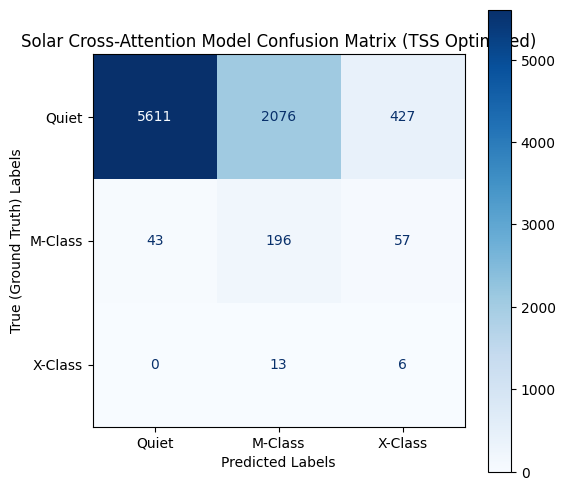

In [9]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Automated TSS Threshold Sweep Function (Updated for Two Heads) ---
def optimize_thresholds(model, dataloader, device):
    """
    Sweeps through probability thresholds on the dataloader using
    reconstructed joint probabilities to maximize TSS for M and X classes.
    """
    model.eval()
    all_probs = []
    all_targets = []

    print("Running TSS threshold sweep to find optimal cutoffs...")
    with torch.no_grad():
        for images, tabular_data, labels in dataloader:
            images = images.to(device)
            tabular_data = tabular_data.to(device).float()
            labels = labels.to(device).long()

            if images.shape[1] == 1:
                images = images.repeat(1, 3, 1, 1)

            # 1. Unpack dual outputs from the two-head model
            binary_logits, severity_logits, _ = model(images, tabular_data)

            # 2. Reconstruct 3-class joint probabilities
            p_binary = torch.softmax(binary_logits, dim=-1)
            p_severity = torch.softmax(severity_logits, dim=-1)
            probabilities = torch.cat([
                p_binary[:, 0:1],                  # P(Quiet)
                p_binary[:, 1:2] * p_severity[:, 0:1], # P(M-Class)
                p_binary[:, 1:2] * p_severity[:, 1:2]  # P(X-Class)
            ], dim=-1)

            all_probs.append(probabilities.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    y_probs = np.vstack(all_probs)
    y_true = np.concatenate(all_targets)

    thresholds = np.linspace(0.05, 0.95, 91)

    # --- Optimize M-Class Threshold (Class 1) ---
    best_m_thresh = 0.20
    best_m_tss = -1.0
    binary_m_true = (y_true == 1).astype(int)

    for thresh in thresholds:
        preds = (y_probs[:, 1] >= thresh).astype(int)
        if preds.sum() == 0 and binary_m_true.sum() > 0:
            continue
        tn, fp, fn, tp = confusion_matrix(binary_m_true, preds, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tss = tpr - fpr
        if tss > best_m_tss:
            best_m_tss = tss
            best_m_thresh = thresh

    # --- Optimize X-Class Threshold (Class 2) ---
    best_x_thresh = 0.15
    best_x_tss = -1.0
    binary_x_true = (y_true == 2).astype(int)

    for thresh in thresholds:
        preds = (y_probs[:, 2] >= thresh).astype(int)
        if preds.sum() == 0 and binary_x_true.sum() > 0:
            continue
        tn, fp, fn, tp = confusion_matrix(binary_x_true, preds, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tss = tpr - fpr
        if tss > best_x_tss:
            best_x_tss = tss
            best_x_thresh = thresh

    print(f"-> Optimal M-Class Threshold: {best_m_thresh:.2f} | Max TSS: {best_m_tss:.4f}")
    print(f"-> Optimal X-Class Threshold: {best_x_thresh:.2f} | Max TSS: {best_x_tss:.4f}\n")

    return float(best_m_thresh), float(best_x_thresh)


# --- 2. Evaluation & Explainability Extraction Function (Updated for Two Heads) ---
def evaluate_and_extract_explainability(model, dataloader, device, x_threshold=0.15, m_threshold=0.20):
    model.eval()
    all_predictions = []
    all_ground_truths = []
    all_attention_maps = []

    with torch.no_grad():
        for images, tabular_data, labels in dataloader:
            images = images.to(device)
            tabular_data = tabular_data.to(device).float()
            labels = labels.to(device).long()

            if images.shape[1] == 1:
                images = images.repeat(1, 3, 1, 1)

            # 1. Unpack dual outputs and attention weights
            binary_logits, severity_logits, attn_weights = model(images, tabular_data)

            B, query_len, key_sequence_length = attn_weights.shape
            H_prime = int(key_sequence_length**0.5)
            W_prime = key_sequence_length // H_prime

            # 2. Reconstruct 3-class joint probabilities
            p_binary = torch.softmax(binary_logits, dim=-1)
            p_severity = torch.softmax(severity_logits, dim=-1)
            probabilities = torch.cat([
                p_binary[:, 0:1],                  # P(Quiet)
                p_binary[:, 1:2] * p_severity[:, 0:1], # P(M-Class)
                p_binary[:, 1:2] * p_severity[:, 1:2]  # P(X-Class)
            ], dim=-1)

            probs_np = probabilities.cpu().numpy()

            # --- CUSTOM THRESHOLD LOGIC ---
            predicted_classes = np.zeros(B, dtype=int)
            for i in range(B):
                if probs_np[i, 2] > x_threshold:
                    predicted_classes[i] = 2  # X-Class
                elif probs_np[i, 1] > m_threshold:
                    predicted_classes[i] = 1  # M-Class
                else:
                    predicted_classes[i] = 0  # Quiet (Default)

            all_predictions.extend(predicted_classes)
            all_ground_truths.extend(labels.cpu().numpy())

            # Reshape attention weights: (B, query_len, H', W')
            spatial_maps = attn_weights.view(B, query_len, H_prime, W_prime).cpu().numpy()
            all_attention_maps.extend(spatial_maps)

    return np.array(all_predictions), np.array(all_ground_truths), np.array(all_attention_maps)


# --- 3. Multi-Class TSS & Metric Calculations ---
def calculate_metrics_and_tss(all_preds, all_targets):
    cm = confusion_matrix(all_targets, all_preds, labels=[0, 1, 2])

    n_classes = cm.shape[0]
    tpr_per_class = np.zeros(n_classes)
    fpr_per_class = np.zeros(n_classes)
    tss_per_class = np.zeros(n_classes)

    total_samples = cm.sum()

    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total_samples - (tp + fn + fp)

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        tpr_per_class[i] = tpr
        fpr_per_class[i] = fpr
        tss_per_class[i] = tpr - fpr

    return cm, tpr_per_class, fpr_per_class, tss_per_class


# --- 4. Execution & Loading Script ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tabular_dim = 9
model = SolarCrossAttention(tabular_dim=tabular_dim, embed_dim=512, num_heads=8)

# Load checkpoint
model_path = "/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/checkpoint_epochV4_hybrid4_2.pt"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
print("Model state dict successfully loaded from Google Drive!")

# A. Automatically find the best thresholds via TSS sweep on the validation loader
optimal_m_thresh, optimal_x_thresh = optimize_thresholds(model, val_loader, device)

# B. Evaluate using the newly discovered optimized thresholds
predictions, ground_truths, attention_maps = evaluate_and_extract_explainability(
    model=model,
    dataloader=val_loader,
    device=device,
    x_threshold=optimal_x_thresh,
    m_threshold=optimal_m_thresh
)

# --- 5. Plotting & Metrics Display ---
cm, tpr, fpr, tss = calculate_metrics_and_tss(predictions, ground_truths)
class_names = ['Quiet', 'M-Class', 'X-Class']

print("\n--- Model Evaluation Summary (Optimized Thresholds) ---")
for i, c_name in enumerate(class_names):
    print(f"{c_name:>8s} | Recall (TPR): {tpr[i]:.4f} | FPR: {fpr[i]:.4f} | TSS: {tss[i]:.4f}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
display.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Solar Cross-Attention Model Confusion Matrix (TSS Optimized)")
plt.xlabel("Predicted Labels")
plt.ylabel("True (Ground Truth) Labels")
plt.show()

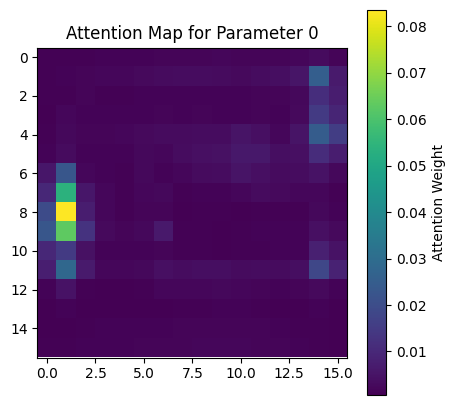

In [10]:
import matplotlib.pyplot as plt

# Grab the 0-th sample, 0-th tabular parameter attention map (shape will be 16x16 automatically)
single_attn_map = attention_maps[0, 0]

plt.figure(figsize=(5, 5))
plt.imshow(single_attn_map, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Attention Weight')
plt.title('Attention Map for Parameter 0')
plt.show()

In [ ]:
  import numpy as np

cm = np.array([
    [7624, 439, 51],   # Actual Quiet
    [225,  69,  2],    # Actual M
    [6,   12,  1]     # Actual X
])
# Original 3-class confusion matrix
#              Pred: Quiet  M      X
# Actual Quiet
# Actual M
# Actual X

# Collapse M and X into one "Flare" class
TN = cm[0, 0]
FP = cm[0, 1] + cm[0, 2]
FN = cm[1, 0] + cm[2, 0]
TP = cm[1, 1] + cm[1, 2] + cm[2, 1] + cm[2, 2]

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

# F1
f1 = (2 * TP) / (2 * TP + FP + FN)

# TSS
tss = (TP / (TP + FN)) - (FP / (FP + TN))

# HSS
hss = (2 * (TP * TN - FP * FN)) / (
    (TP + FN) * (FN + TN) +
    (TP + FP) * (FP + TN)
)

print("F1:", f1)
print("TSS:", tss)
print("HSS:", hss)

TN: 7624
FP: 490
FN: 231
TP: 84
F1: 0.1889763779527559
TSS: 0.20627721633390847
HSS: 0.14785296366493492
